<a href="https://colab.research.google.com/github/DiegoFreitasCC/telemedicine-health-analytics/blob/main/Trabalho2_SIGA_Analise_Clinica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<>:20: SyntaxWarning: invalid escape sequence '\$'
<>:20: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_18410/2743806225.py:20: SyntaxWarning: invalid escape sequence '\$'
  df['Valor_Consulta'] = df['Valor_Consulta'].astype(str).str.replace('R\$ ', '', regex=True)


--- A. FASE DE EXTRAÇÃO E LIMPEZA (ETL) ---
Duplicatas removidas: 3 linhas.
ETL Concluído! Não há mais dados nulos.

--- B. ANÁLISE DE GESTÃO (KPIs) ---
1. Ticket Médio por Modalidade:
Modalidade
Online        168.40
Presencial    217.62
Name: Valor_Consulta, dtype: float64

2. Faturamento Total por Especialidade:
Especialidade
Cardiologia       2832.189655
Ortopedia         2732.189655
Dermatologia      2377.000000
Pediatria         1970.000000
Clínica Médica    1620.000000
Name: Valor_Consulta, dtype: float64

3. Top 3 Pacientes VIPs:
Paciente
Fernanda Costa    2434.0
Pamera Freitas    1846.0
Marcos Pereira    1522.0
Name: Valor_Consulta, dtype: float64

4. Sazonalidade (Consultas por Mês):
Mes
2025-01    15
2025-02    10
2025-03    13
2025-04     9
2025-05    13
Name: ID_Consulta, dtype: int64

--- C. VISUALIZAÇÃO DE DADOS ---


/tmp/ipykernel_18410/2743806225.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=faturamento_esp.values, y=faturamento_esp.index, ax=axes[0, 0], palette="viridis")
/tmp/ipykernel_18410/2743806225.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Modalidade', y='Valor_Consulta', data=df, ax=axes[1, 1], palette="Set2")


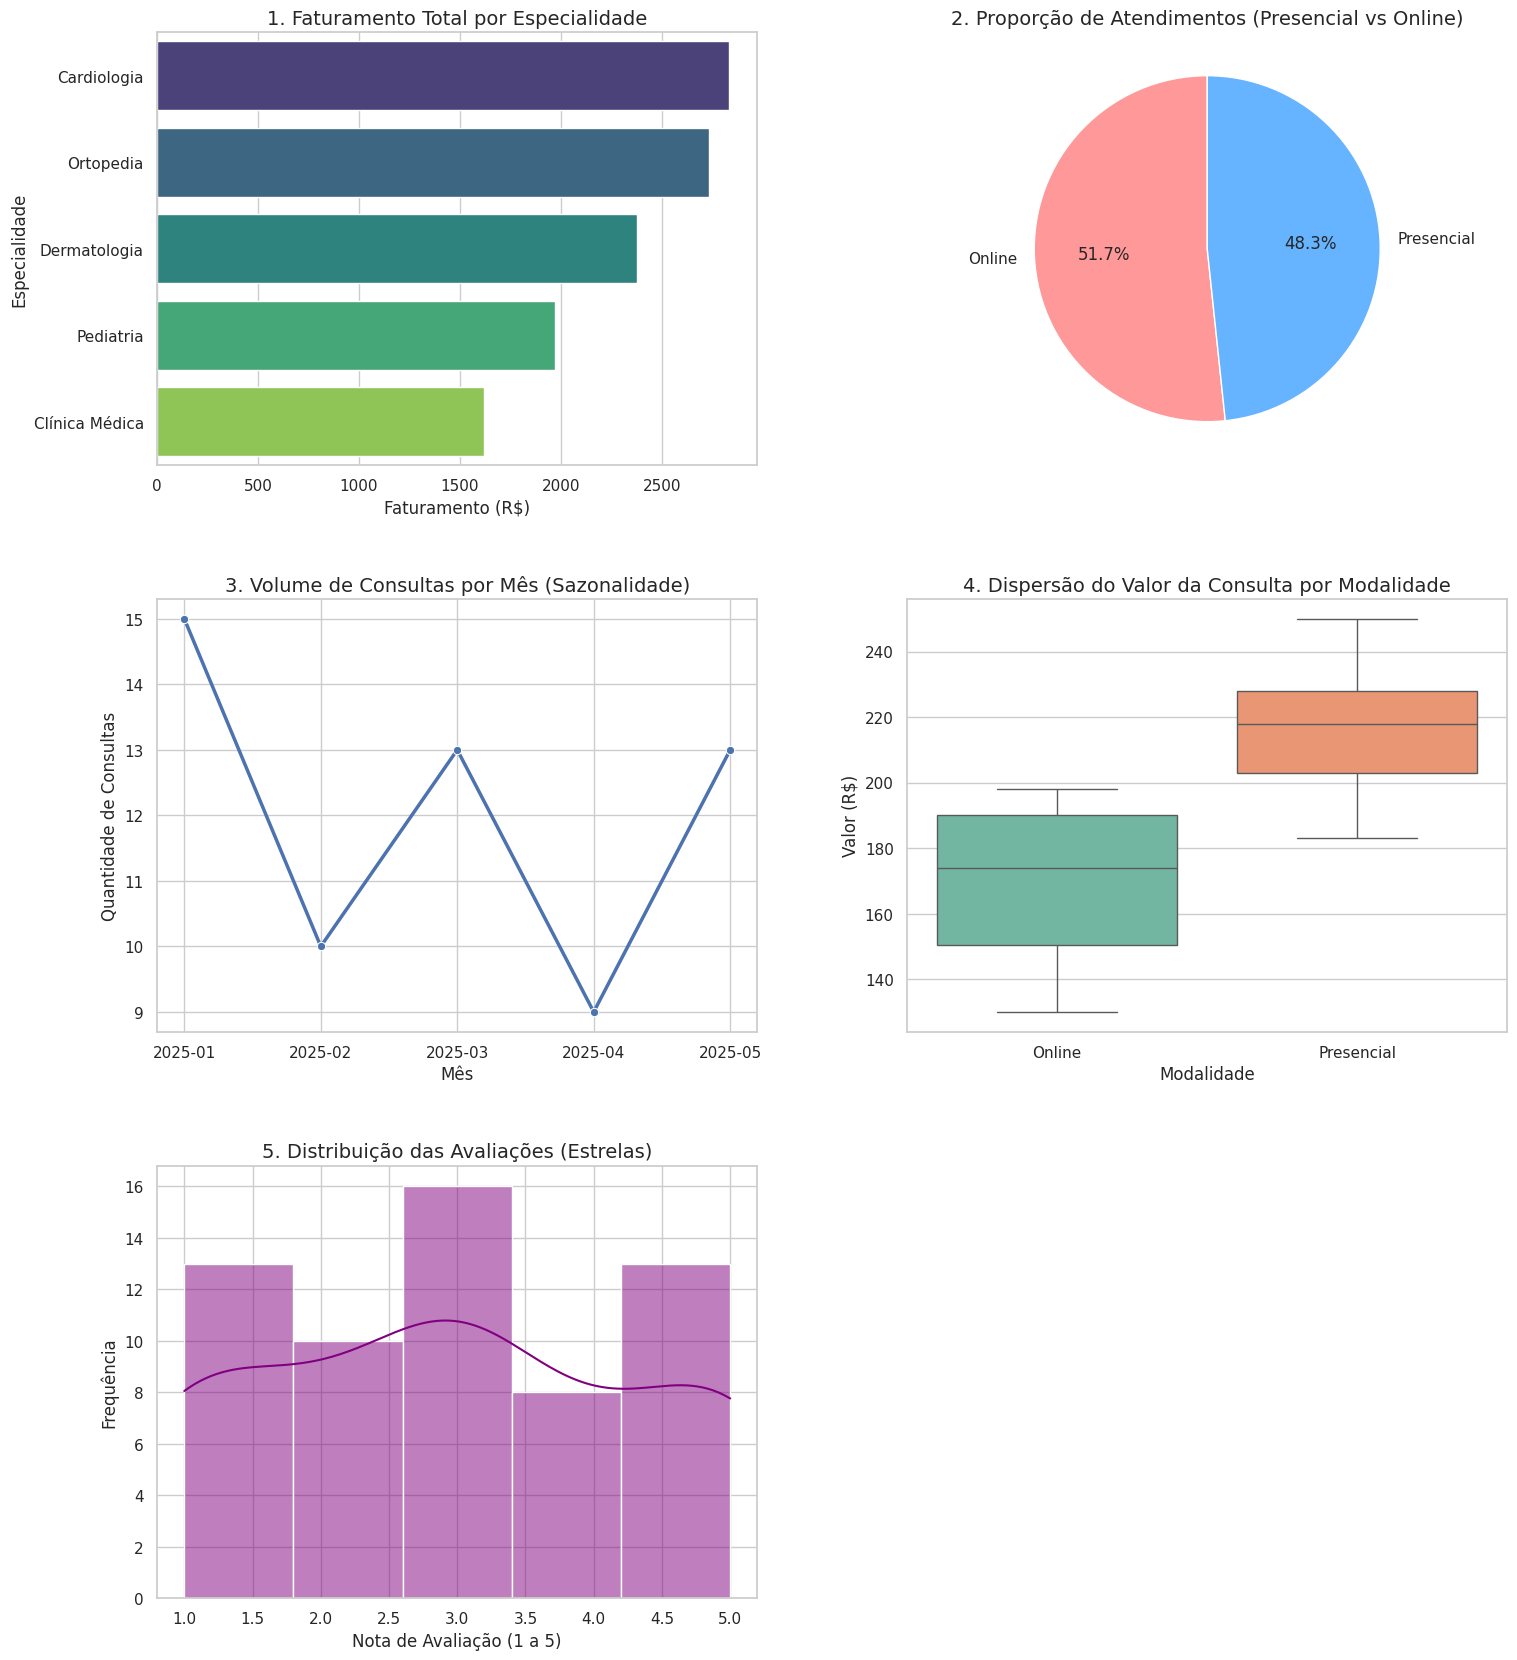

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")

print("--- A. FASE DE EXTRAÇÃO E LIMPEZA (ETL) ---")
# 1. Extração
df = pd.read_csv('faturamento_clinicas.csv')
linhas_antes = len(df)

# 2. Limpeza de Duplicatas
df = df.drop_duplicates()
linhas_depois = len(df)
print(f"Duplicatas removidas: {linhas_antes - linhas_depois} linhas.")

# 3. Conversão de Tipos e Limpeza de Strings
# Tirando o "R$ " e convertendo para float
df['Valor_Consulta'] = df['Valor_Consulta'].astype(str).str.replace('R\$ ', '', regex=True)
df['Valor_Consulta'] = pd.to_numeric(df['Valor_Consulta'], errors='coerce')

# Convertendo Data para datetime
df['Data'] = pd.to_datetime(df['Data'])
# Criando coluna de Mês para sazonalidade
df['Mes'] = df['Data'].dt.strftime('%Y-%m')

# 4. Tratamento de Valores Ausentes (Missing Values)
# Preenchendo o Valor_Consulta vazio com a média da clínica
media_valor = df['Valor_Consulta'].mean()
df['Valor_Consulta'] = df['Valor_Consulta'].fillna(media_valor)

# Preenchendo a Avaliação vazia com a mediana
mediana_aval = df['Avaliacao_Estrelas'].median()
df['Avaliacao_Estrelas'] = df['Avaliacao_Estrelas'].fillna(mediana_aval)

print("ETL Concluído! Não há mais dados nulos.\n")


print("--- B. ANÁLISE DE GESTÃO (KPIs) ---")
# KPI 1: Ticket Médio por Modalidade
ticket_medio = df.groupby('Modalidade')['Valor_Consulta'].mean().round(2)
print(f"1. Ticket Médio por Modalidade:\n{ticket_medio}\n")

# KPI 2: Faturamento Total por Especialidade
faturamento_esp = df.groupby('Especialidade')['Valor_Consulta'].sum().sort_values(ascending=False)
print(f"2. Faturamento Total por Especialidade:\n{faturamento_esp}\n")

# KPI 3: Top 3 Pacientes (Maior Geração de Receita)
top_pacientes = df.groupby('Paciente')['Valor_Consulta'].sum().nlargest(3)
print(f"3. Top 3 Pacientes VIPs:\n{top_pacientes}\n")

# KPI 4: Sazonalidade (Quantidade de Consultas por Mês)
consultas_mes = df.groupby('Mes')['ID_Consulta'].count()
print(f"4. Sazonalidade (Consultas por Mês):\n{consultas_mes}\n")


print("--- C. VISUALIZAÇÃO DE DADOS ---")
# Criando uma figura com 5 subplots (gráficos)
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.tight_layout(pad=6.0)

# Gráfico 1: Faturamento por Especialidade (Barplot)
sns.barplot(x=faturamento_esp.values, y=faturamento_esp.index, ax=axes[0, 0], palette="viridis")
axes[0, 0].set_title('1. Faturamento Total por Especialidade', fontsize=14)
axes[0, 0].set_xlabel('Faturamento (R$)')
axes[0, 0].set_ylabel('Especialidade')

# Gráfico 2: Distribuição de Modalidade (Pie Chart)
modalidade_counts = df['Modalidade'].value_counts()
axes[0, 1].pie(modalidade_counts, labels=modalidade_counts.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
axes[0, 1].set_title('2. Proporção de Atendimentos (Presencial vs Online)', fontsize=14)

# Gráfico 3: Sazonalidade ao longo dos meses (Lineplot)
sns.lineplot(x=consultas_mes.index, y=consultas_mes.values, ax=axes[1, 0], marker="o", color="b", linewidth=2.5)
axes[1, 0].set_title('3. Volume de Consultas por Mês (Sazonalidade)', fontsize=14)
axes[1, 0].set_xlabel('Mês')
axes[1, 0].set_ylabel('Quantidade de Consultas')

# Gráfico 4: Dispersão dos Valores por Modalidade (Boxplot)
sns.boxplot(x='Modalidade', y='Valor_Consulta', data=df, ax=axes[1, 1], palette="Set2")
axes[1, 1].set_title('4. Dispersão do Valor da Consulta por Modalidade', fontsize=14)
axes[1, 1].set_xlabel('Modalidade')
axes[1, 1].set_ylabel('Valor (R$)')

# Gráfico 5: Histograma das Avaliações dos Pacientes (Histplot)
sns.histplot(df['Avaliacao_Estrelas'], bins=5, kde=True, ax=axes[2, 0], color="purple")
axes[2, 0].set_title('5. Distribuição das Avaliações (Estrelas)', fontsize=14)
axes[2, 0].set_xlabel('Nota de Avaliação (1 a 5)')
axes[2, 0].set_ylabel('Frequência')

# Escondendo o último quadro vazio (linha 3, coluna 2)
fig.delaxes(axes[2, 1])

plt.show()

# Nova seção